This is a short notebook which compares several properties of SPDC calculated using two different methods. First method involves solving the equations of motion (EoMs) in $(k,t)$ space. These are the well-known and accepted solutions which conserve equal-time commutation relations and allow for easy construction of the *ket* regardless of the dispersion relations of the modes. Second method involves solving equations of motion in $(z,\omega)$ space, which are derived using the *Generator of Momentum*. Previous derivations of $(z,\omega)$ equations of motion did not necessarily conserve commutation relations and the derivations usually involved assuming linear dispersions (c.f. `SPulsed_lin` function) (the extension to higher orders of dispersion are not well justified/verified). Here we apply both methods for arbitrary dispersions and find that both methods agree quite well (up to numerical errors/implementation).

On the topic of numerical errors/implementation, to properly compare both methods we need to address a few things. For the Generator of Momentum method, it is implied that time is taken from -$\infty$ to $\infty$, which is not how the $(k,t)$ EoMs are solved. This is already a source of error (albeit small since we are solving in a way such that the pump is completely outside the nonlinear region both before and after the interaction). The *Generator of Momentum* method also only considers the interaction region, and so only considers $z$ from -L/2 to L/2. When including higher order dispersion, it is important to include the point of origin in the solution for the pump and make sure that we assume the pump starts at the same location that it does in the $(k,t)$ method. Note that to compare results, we remove the free propagating phases of the signal and idler modes for both methods(still important to keep the pump dispersion).

Furthermore, to actually compare the two methods we convert the $(z,\omega)$ equations of motion to $(z,\omega[k])/(z,k)$ ones all the while keeping the pump as a function of frequency. At the level of the Hamiltonian, we are taking $\int d\omega_s d\omega_i d\omega_p$ to $\int dk_s dk_i d\omega_p$ (including the proper Jacobian and normalization factors for the operators). The interaction term (for the signal EoM) is thus  $\int dk'  \beta(\omega_s(k)+\omega_i(k'),z_0)*exp(iK_p[ \omega_s(k)+\omega_i(k')] (z-z_0))$. For these reasons we define a new function which generates the propagator in $(z,k)$ space directly in this notebook.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from custom_poling.core.target import Target
from custom_poling.core.custom_crystal import CustomCrystal
from NeedALight.spdc import Total_propK, JSA
from NeedALight.utils import phases
from scipy.linalg import expm

We begin by defining the new propagator function that generates the Heisenberg propagator for the $(z,\omega[ k])$ equations of motion. We can then use our pre-defined JSA function to generate the wanted quantities.

In [4]:
def prop_zk(ws,wi,k,kp_w,vp,z_list,domain,z0,Lambda_w):
    """Generates the Heisenberg propagator in (z,k) space using the equations of motion obtained from the Generator of Momentum 
    
    Args:
        ws (array): signal dispersion relation
        wi (array): idler dispersion relation
        k (array): momenta values of interest 
        kp_w (function): interpolation function for pump momenta (inverse of disperersion relation)
        vp (array): pump group velocity
        z_list (array): discretized interaction region
        domain (array): poling configuration
        z0 (float): initial position of pump, same as (k,t) method
        Lambda_w (function): Pump envelope function in frequency space

    Returns:
        K (array): Heisenberg Propagator in (z,k) space
    """
    dk = k[1]-k[0]
    dz = z_list[1]-z_list[0]
    # Initializing
    K = np.identity(2*len(k), dtype=np.complex128)


    # Constructing the diagonal blocks
    Rs = np.diag(1j * k)
    Ri = np.diag(-1j * k)

    #Note that for the pump, we explicitely remove the linear free-propagating phases here (For plotting purposes later)
    for i in range(len(z_list)):
        F = 1j * Lambda_w(ws[:,np.newaxis]+wi)*np.exp(1j*((kp_w(ws[:,np.newaxis]+wi))*(z_list[i]-z0)+(ws[:,np.newaxis]+wi)*z0/vp))*domain[i]*dk/np.sqrt(2*np.pi*(vp))
        Q = np.block([[Rs, F], [np.conjugate(F).T, Ri]])
        K = expm(Q * dz) @ K



    return K

This is a short example for using the momentum-time equations of motion for twin-beam generation. Note that this only works for a single pass configuration and does not include self- and cross-phase modulation.
We begin with setting up the parameters. *Note that current parameters are set to work with an unpoled crystal*

In [5]:
#Parameters
Np = 0.02 # Number of pump photons: Vary this to modify gain values
vp = 0.1  # pump velocity
l = 1.0  # amplification region length
sig = 1  # pump wave packet spread
a = 1.61 / 1.13  # from symmetric grp vel matching
z0=-l

def symmetric_v(vp, sig, l, a):
    vi = vp / (1 - 2 * a * vp / (l * sig))
    vs = vp / (1 + 2 * a * vp / (l * sig))
    return vs, vi

vs, vi = symmetric_v(vp, sig, l, a)

# Crystal properties
Ndomain = 1000 #Number of spatial points for non-linear/crystal grid
dz = (l) / Ndomain
domain_width = dz
number_domains = Ndomain
L = number_domains * domain_width

#Momenta grid
nk=201 #Number of momentum values: Always choose a number ending in 1. That way you always have a momentum value = 0
k_ft = 200/L 
dk = k_ft/nk
k = np.arange(-k_ft/2,k_ft/2,dk)

Run the next cell to generate an apodized domain giving rise to a GAUSSIAN phase matching function in the low gain. Definition of Gaussian pump envelope also included.

In [4]:
# Numerical integration parameters for Crystal Structure
k0 = np.pi / domain_width
k_range = 100/L
dkc = k_range/401
k_array = np.arange(k0-k_range/2,k0+k_range/2,dkc)

# Create a custom crystal object
custom_crystal_gauss = CustomCrystal(domain_width,number_domains)
domain_middles_gauss = custom_crystal_gauss.domain_middles

#Define and plot the target function
std = 10
height = 0.025
target_pmf_gauss = lambda k:1j*height*np.exp(-(k-k0)**2/(2*std**2))*np.exp(1j * L/2 * k)
target_gauss = Target(target_pmf_gauss,k_array)

# Compute and plot the target amplitude
target_amplitude_gauss = target_gauss.compute_amplitude(k0,domain_middles_gauss)

# Compute and plot the custom domains
custom_domains_gauss = custom_crystal_gauss.compute_domains(target_amplitude_gauss,k0)
domain = custom_domains_gauss * np.asarray([1, -1] * int(Ndomain / 2)+[1]) #The multiplication here sets the central momenta to 0


# defining gaussian pump pulse in momentum space with initial position z0
def pump(x, scale=1):
    return np.exp(-((x) ** 2) / (2 * ((sig/vp)/scale) ** 2)) / np.power(np.pi * ((sig/vp)/scale)**2, 1 / 4)*np.exp(-1j*x*z0)

#Proper scale factor so that Gaussian PMF and Gaussian Pump have the same width
sc=std/(2*a)

Run the next cell to generate an apodized domain giving rise to a SINC phase matching function in the low gain. Definition of Gaussian pump envelope also included.

In [6]:
# Create a custom crystal object
custom_crystal_gauss = CustomCrystal(domain_width,number_domains)
domain_middles_gauss = custom_crystal_gauss.domain_middles

# defining gaussian pump pulse in momentum space with initial position z0
def pump(x, scale=1):
    return np.exp(-((x) ** 2) / (2 * ((sig/vp)/scale) ** 2)) / np.power(np.pi * ((sig/vp)/scale)**2, 1 / 4)*np.exp(-1j*x*z0)

#Domain for a tophat potential
domain=np.asarray([1] * int(Ndomain)+[1]) #
sc=1

Next we define the dispersion relations in momentum($k$) space and the list of $z$ points where the interaction is non-zero. We also include the time interval. Note that for good convergence/agreement between methods for the values chosen, a time step of 0.05 or lower is needed. However, this takes a while and for general checks which still give good comparisons, a step of ~0.2 is fine. We solve for the pump evolution in $(z,t)$ by taking the Fourier Transform of the trivial $(k,t)$ solution. Note that we define a different grid of momenta to take said F.T.

In [7]:
#Defining dispersion relations, (z,t) grids, and pump envolope as a (t,z) matrix

#Dispersion relations. Unlike (z,w) code, we can allow for higher orders of dispersions (terms propto k**2 and higher)
ws = vs*k + 0.00025*k**2 #-0.0000006*k**3
wi = vs*k + 0.0001*k**2 #+0.0000002*k**3


#Spatial grid values for the non-linear region/crystal.
z_list = domain_middles_gauss-l/2-dz/2

#z_list = z_list1[0:-1]

#Time grid
DELTAt=0.2
#Play around with time vector at your leisure. Currently chosen such that all pulses completely leave the crystal.
#Also chosen such that pump pulse ends at z=1.
t=np.arange(0,20+DELTAt,DELTAt)   


#Pump function in (t,z) for momentum profile specified above and dispersion specified below.
#To help with FT we define a different momenta grid
nkp=801 #Number of momentum values for pump FT
kp_ft = 1000/L 
dkp = kp_ft/nkp
kp = np.arange(-kp_ft/2,kp_ft/2,dkp)

#Pump dispersion relation
wp = vp*kp - 0.0001*kp**2

Lambda = np.zeros([len(t),len(z_list)], dtype=np.complex128)
for i in range(len(t)):
    Lambda[i,:] = np.sqrt(Np)*np.sum(np.exp(-1j*wp[:,np.newaxis]*t[i])*np.exp(1j*kp[:,np.newaxis]*(z_list))*pump(kp[:,np.newaxis],scale=1/sc),axis=0)*dkp/np.sqrt(2*np.pi)

Verifying that dispersion is properly one-to-one for the choice of dispersion and range of momenta. This is the regime we are considering and also the assumptions built into the code. If not 1-1, need to modify parameters.

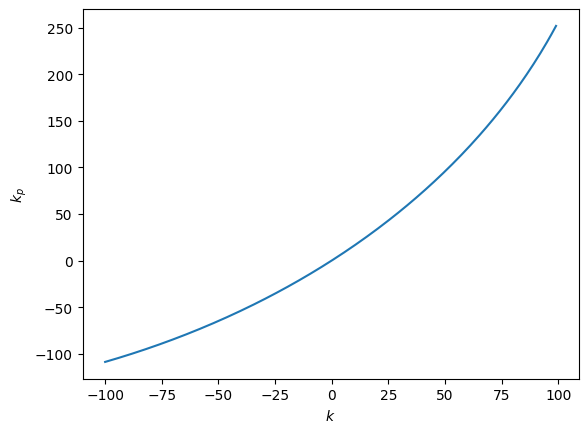

In [8]:
#To invert the pump dispersion relation, we use the interpolating function with \omega_p as the x-variable. 
# Allowing us to find k_p as a function of \omega_s+\omega_i which are themselves functions of 'k' 
kp_w = lambda x : np.interp(x,wp,kp)

fig, ax1 = plt.subplots()

#We only look at the diagonal part which includes the extremal values of \omega_s+\omega_i.
ax1.plot(k,np.diag(kp_w(ws[:,np.newaxis]+wi))) 
ax1.set_xlabel(r"$k$")
ax1.set_ylabel(r"$k_p$")
plt.show()

For the single pass structure, we can simply make use of all of the functions to generate all the desired/relevant quantities. The JSA function will give us the JSA, the Schmidt number, as well as all the relevant moments.

In [9]:
#This generates the total propagator for the full time.
K = Total_propK(domain,Lambda,z_list,k,t,ws,wi)


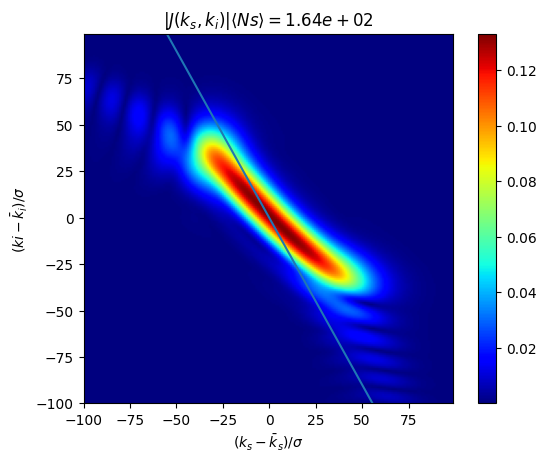

Schmidt Number: 2.012197


In [16]:
#We first remove the free-propagating phases.
Kphaseless = phases(K,-ws,-wi,t[-1]+DELTAt)

#Generates JSA and other relevant matrices.
J, Ns, Schmidt, M, Nums, Numi = JSA(Kphaseless,dk)

fig, ax = plt.subplots()
im = ax.imshow(np.abs(J), cmap="jet", origin="lower", extent=[k[0],k[nk-1],k[0],k[nk-1]])
ax.plot(-(vs/vi)*k,k)
ax.set_xlabel(r"$(k_{s}-\bar{k}_{s})/\sigma$")
ax.set_ylabel(r"$(k{i}-\bar{k}_{i})/\sigma$")
ax.set_title(r"$|J(k_{s}, k_{i})|    \langle Ns \rangle = %1.2e $" %Ns)
plt.colorbar(im, orientation="vertical")
plt.show()
print('Schmidt Number: %f' %Schmidt)

Here we look at the First output signal Schmidt mode. Note that we multiply by a phase factor such that the imaginary part is 0 at the origin. Can look at other Schmidt modes by changing the value of 'mark'.

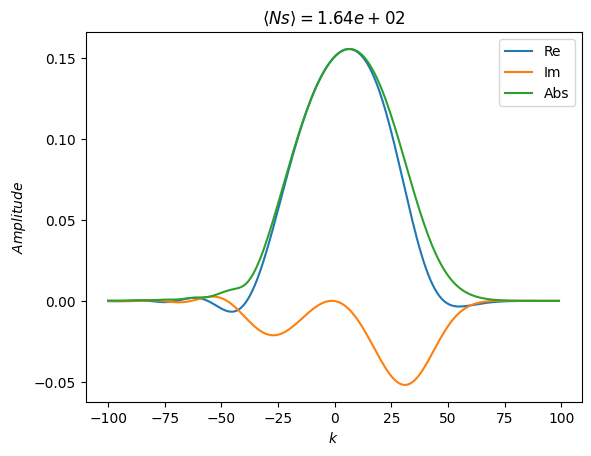

In [17]:
mark=1 #this just takes the first eigenmode of interest. Choose a different value to look at different ones.
val1, u1 = np.linalg.eigh(Nums)

fig, ax1 = plt.subplots()

ax1.plot(k, np.real(np.exp(-1j*np.angle(u1[(nk-1)//2,-mark]))*u1[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1.plot(k, np.imag(np.exp(-1j*np.angle(u1[(nk-1)//2,-mark]))*u1[:,-mark]), label='Im')
ax1.plot(k, np.abs(np.exp(-1j*np.angle(u1[(nk-1)//2,-mark]))*u1[:,-mark]), label='Abs')
ax1.set_xlabel(r"$k$")
ax1.set_ylabel(r"$Amplitude$")
ax1.set_title(r"$\langle Ns \rangle= %1.2e$" %Ns)
ax1.legend()
plt.show()

Next we calculate things using the $(z,\omega[k])$ method. First we define the pump envelope function in frequency space.

In [18]:
#We use all the pre-defined quantities above. Specifying pump envelope function in frequency space

def pump2(x, scale=1):
    return np.sqrt(Np)*np.exp(-((x) ** 2) / (2 * (sig*scale) ** 2)) / np.power(np.pi * (sig*scale)**2, 1 / 4)

#Pump envelope function with proper scaling (defined when specifying poling domain).
Lambda_w = lambda x: pump2(x,scale=sc)


In [19]:
#Generating the Heisenberg propagator.
K2 = prop_zk(ws,wi,k,kp_w,vp,z_list,domain,z0,Lambda_w)

Next we plot the JSA obtained from the $(z,\omega[k])$ method. For more comparative ease, we re-include a plot of the (k,t) JSA obtained above.

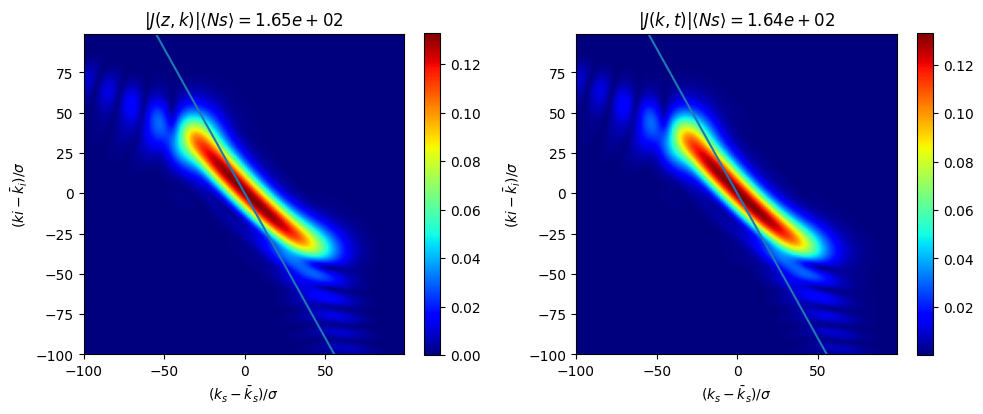

Schmidt Number (z,k): 2.012142
Schmidt Number (k,t): 2.012197


In [23]:
#We first remove the free propagating phases.
Kphaseless2 = phases(K2,k,k,len(z_list)*dz)

#Generates JSA and other relevant matrices.
J2, Ns2, Schmidt2, M2, Nums2, Numi2 = JSA(Kphaseless2,dk)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im = axs[0].imshow(np.abs(J2), cmap="jet", origin="lower", extent=[k[0],k[nk-1],k[0],k[nk-1]])
axs[0].plot(-(vs/vi)*k,k)
axs[0].set_xlabel(r"$(k_{s}-\bar{k}_{s})/\sigma$")
axs[0].set_ylabel(r"$(k{i}-\bar{k}_{i})/\sigma$")
axs[0].set_title(r"$|J(z, k)|    \langle Ns \rangle = %1.2e $" %Ns2)
plt.colorbar(im, orientation="vertical")

im2 = axs[1].imshow(np.abs(J), cmap="jet", origin="lower", extent=[k[0],k[nk-1],k[0],k[nk-1]]) #The transpose is to properly have Idler on the y-axis.
axs[1].plot(-(vs/vi)*k,k)
axs[1].set_xlabel(r"$(k_{s}-\bar{k}_{s})/\sigma$")
axs[1].set_ylabel(r"$(k{i}-\bar{k}_{i})/\sigma$")
axs[1].set_title(r"$|J(k, t)|    \langle Ns \rangle = %1.2e $" %Ns)
plt.colorbar(im2, orientation="vertical")

fig.tight_layout()
plt.show()
print('Schmidt Number (z,k): %f' %Schmidt2)
print('Schmidt Number (k,t): %f' %Schmidt)


The average number of signal photons (Ns) and the Schmidt number (K) for both methods get closer in agreement as we decrease the timestep as mentioned above.

We now print out certain values to compare both methods

In [27]:
print('Schmidt Numbers')
print('(k,t) method: %f' %Schmidt)
print("(z,k) method: %f" %Schmidt2)

print('Signal Photon Numbers')
print('(k,t) method: %f' %Ns)
print('(z,k) method: %f' %Ns2)

print('Max absolute JSA value')
print('(k,t) method: %f' %np.amax(np.abs(J)))
print('(z,k) method: %f' %np.amax(np.abs(J2)))

print('Error between max absolute JSA values: %f' %(np.amax(np.abs(J2-J))/np.amax(np.abs(J))))

Schmidt Numbers
(k,t) method: 2.012197
(z,k) method: 2.012142
Signal Photon Numbers
(k,t) method: 163.924144
(z,k) method: 165.292146
Max absolute JSA value
(k,t) method: 0.133157
(z,k) method: 0.132931
Error between max absolute JSA values: 0.020096


Here we calculate some form of Fidelity between the two different Joint-Spectral Amplitudes

In [29]:
Jn = np.abs(J) / np.linalg.norm(np.abs(J))
Jtn = np.abs(J2) / np.linalg.norm(np.abs(J2))
Fidelity = np.sum(Jn * np.conjugate(Jtn))

print(Fidelity)

0.9999245130249835


Here is a plot of the difference between the two JSAs.

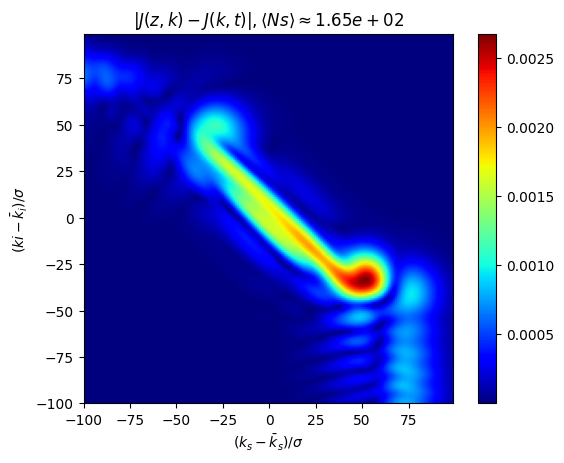

In [30]:
fig, ax = plt.subplots()
im = ax.imshow(np.abs(J2-J), cmap="jet", origin="lower", extent=[k[0],k[nk-1],k[0],k[nk-1]])
ax.set_xlabel(r"$(k_{s}-\bar{k}_{s})/\sigma$")
ax.set_ylabel(r"$(k{i}-\bar{k}_{i})/\sigma$")
ax.set_title(r"$|J(z, k)-J(k,t)|,    \langle Ns \rangle \approx %1.2e $" %Ns2)
plt.colorbar(im, orientation="vertical")
plt.show()

Next we plot the same Schmidt mode as before but for the (z,k) case

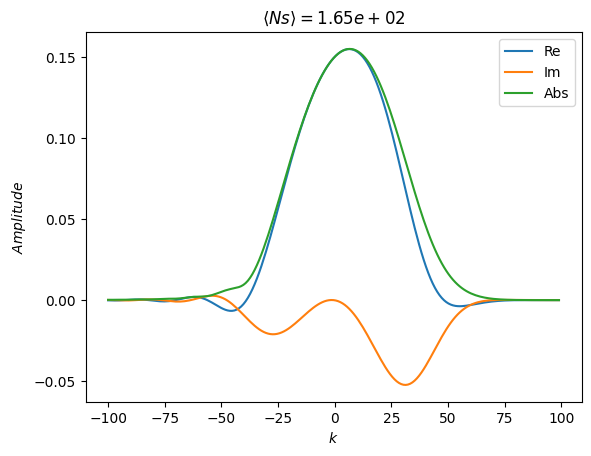

In [31]:
#this just takes the first eigenmode of interest. Choose a different value to look at different ones.
val2, u2 = np.linalg.eigh(Nums2)
fig, ax1 = plt.subplots()

ax1.plot(k, np.real(np.exp(-1j*np.angle(u2[(nk-1)//2,-mark]))*u2[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1.plot(k, np.imag(np.exp(-1j*np.angle(u2[(nk-1)//2,-mark]))*u2[:,-mark]), label='Im')
ax1.plot(k, np.abs(np.exp(-1j*np.angle(u2[(nk-1)//2,-mark]))*u2[:,-mark]), label='Abs')
ax1.set_xlabel(r"$k$")
ax1.set_ylabel(r"$Amplitude$")
ax1.set_title(r"$\langle Ns \rangle= %1.2e$" %Ns2)
ax1.legend()
plt.show()

Here we plot the Schmidt modes on the same plot and see that they are very indistinguishable. We also print out the overlap between both.

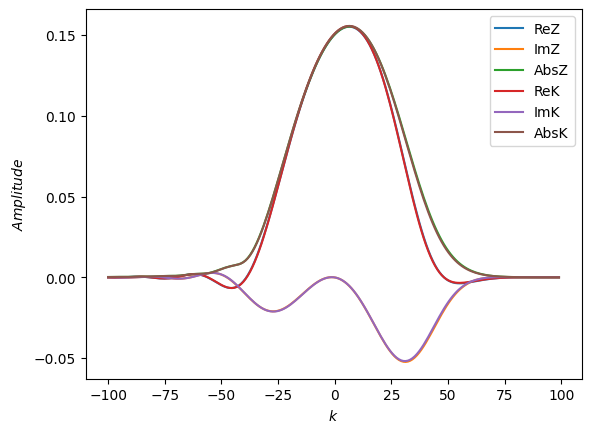

0.9999590756648931


In [33]:
fig, ax1 = plt.subplots()

ax1.plot(k, np.real(np.exp(-1j*np.angle(u2[(nk-1)//2,-mark]))*u2[:,-mark]), label='ReZ') 
ax1.plot(k, np.imag(np.exp(-1j*np.angle(u2[(nk-1)//2,-mark]))*u2[:,-mark]), label='ImZ')
ax1.plot(k, np.abs(np.exp(-1j*np.angle(u2[(nk-1)//2,-mark]))*u2[:,-mark]), label='AbsZ')
ax1.plot(k, np.real(np.exp(-1j*np.angle(u1[(nk-1)//2,-mark]))*u1[:,-mark]), label='ReK') 
ax1.plot(k, np.imag(np.exp(-1j*np.angle(u1[(nk-1)//2,-mark]))*u1[:,-mark]), label='ImK')
ax1.plot(k, np.abs(np.exp(-1j*np.angle(u1[(nk-1)//2,-mark]))*u1[:,-mark]), label='AbsK')
ax1.set_xlabel(r"$k$")
ax1.set_ylabel(r"$Amplitude$")
ax1.legend()
plt.show()

print(np.abs(np.vdot(u2[:,-mark],u1[:,-mark]))**2)